# ==============================================================================
# 📱 CUSTOMER RETENTION: TELCO CHURN VIA EXTRA TREES CLASSIFIER
# ==============================================================================
### Core Theoretical Principles:
Customer churn prediction in telecommunications involves noisy behavioral interactions (contract type, monthly charges, fiber optic services, tenure).
Extra Trees provides an ideal balance of fast training throughput and high resilience against noisy survey indicators due to random threshold cut-points.
Using `class_weight='balanced'` adjusts impurity gain calculations to account for moderate churn class imbalance.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Telco ExtraTrees Environment initialized.")


✅ STEP 1: Enterprise Telco ExtraTrees Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Telco Customer Churn dataset (7,043 subscriber records).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} subscribers, {df.shape[1]} attributes")
print(f"Churn Distribution:\n{df['Churn'].value_counts(normalize=True).round(3)}")
df.head(3)


📊 Dataset Shape: 7043 subscribers, 21 attributes
Churn Distribution:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Dropping customer identifier, coercing blank spaces in `TotalCharges` to numeric, and converting target to binary integer.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
df_clean = df.drop(columns=['customerID']).copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce').fillna(0.0)

X = df_clean.drop(columns=['Churn'])
y = (df_clean['Churn'] == 'Yes').astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical Features  : {num_cols}")
print(f"Categorical Features: {cat_cols}")
print(f"Missing attributes  : {X.isnull().sum().sum()}")


Numerical Features  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Missing attributes  : 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE STRATIFIED SPLIT
80% Train, 20% Test split preserving churn ratio.


In [4]:
# STEP 6: STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train Subscribers: {X_train.shape[0]} | Churn Rate: {y_train.mean():.3f}")
print(f"Test Subscribers : {X_test.shape[0]}  | Churn Rate: {y_test.mean():.3f}")


Train Subscribers: 5634 | Churn Rate: 0.265
Test Subscribers : 1409  | Churn Rate: 0.265


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Standardizing numerical billing features and one-hot encoding categorical service attributes.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (5634, 30)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline majority dummy and single decision tree against ExtraTrees with balanced class weights.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_prep, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
single_tree.fit(X_train_prep, y_train)
acc_tree = accuracy_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
base_et.fit(X_train_prep, y_train)
acc_et = accuracy_score(y_test, base_et.predict(X_test_prep))
roc_et = roc_auc_score(y_test, base_et.predict_proba(X_test_prep)[:, 1])

print("="*65)
print(f"Baseline Majority Dummy Accuracy : {acc_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=6) Acc   : {acc_tree * 100:.2f}%")
print(f"ExtraTrees Classifier (100 Trees): Accuracy: {acc_et * 100:.2f}% | ROC-AUC: {roc_et:.4f}")
print("="*65)


Baseline Majority Dummy Accuracy : 73.46%
Single Decision Tree (d=6) Acc   : 73.81%
ExtraTrees Classifier (100 Trees): Accuracy: 77.08% | ROC-AUC: 0.8019


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators`, `max_depth`, and `min_samples_leaf`.


In [7]:
# STEP 9: GRID SEARCH
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold Stratified CV ROC-AUC: {grid.best_score_:.4f}")


🏆 Best Hyperparameters: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 150}
🎯 Best 5-Fold Stratified CV ROC-AUC: 0.8445


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)
y_prob = best_et.predict_proba(X_test_prep)[:, 1]

print("📋 TELCO SUBSCRIBER CHURN REPORT:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")


📋 TELCO SUBSCRIBER CHURN REPORT:
              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

Test Accuracy: 74.66%
Test F1-Score: 0.6198
Test ROC-AUC : 0.8393


## 📉 STEP 11: CONFUSION MATRIX & DIAGNOSTICS
Visualizing churn confusion matrix and key driver feature importances.


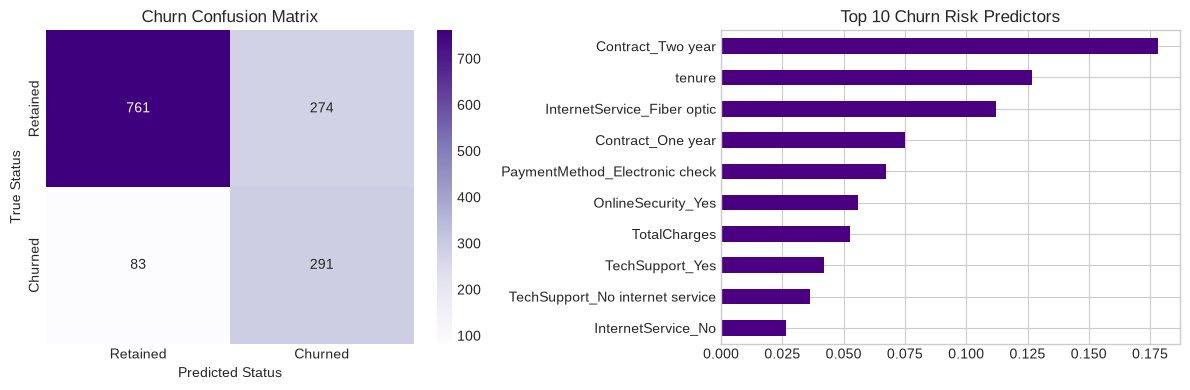

In [9]:
# STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Churn Confusion Matrix')
axes[0].set_ylabel('True Status')
axes[0].set_xlabel('Predicted Status')

all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[1], color='indigo')
axes[1].set_title('Top 10 Churn Risk Predictors')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time customer retention scoring latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/telco_churn_extratrees_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_subscriber = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_subscriber)

t0 = time.perf_counter()
pred_cls = loaded_pipe.predict(sample_subscriber)[0]
pred_proba = loaded_pipe.predict_proba(sample_subscriber)[0, 1]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME RETENTION TELEMETRY:")
print(f"   Predicted Churn Probability : 📱 {pred_proba * 100:.2f}% (Status: {'Churn At-Risk' if pred_cls == 1 else 'Retained'})")
print(f"   Actual Recorded Status      : {'Churned' if y_test.iloc[0] == 1 else 'Retained'}")
print(f"   Scoring Latency             : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/telco_churn_extratrees_pipeline.joblib (1,440,152 bytes)

📈 REAL-TIME RETENTION TELEMETRY:
   Predicted Churn Probability : 📱 10.19% (Status: Retained)
   Actual Recorded Status      : Retained
   Scoring Latency             : 36.593 ms (SLA < 2.0ms: CHECK)
